In [1]:
import xarray as xr
import sys, os
from sklearn.metrics import mean_squared_error
import scipy.stats as stats
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
#print(curdir)
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")
full_ebaf_filename = "23Aug/CERES_EBAF-TOA_Ed4.1_Subset_200003-202203.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

In [2]:
# Load the data
full_data_path = base_path / full_ebaf_filename
ds = xr.open_dataset(full_data_path)

# Albedo Symmetry Example

In [3]:
sw_all_sky_14 = create_hemisphere_data(ds["toa_sw_all_mon"], start_yr="2001", end_yr="2023", time_weighting=3)
sw_all_sky_bad_temporal = create_hemisphere_data(ds["toa_sw_all_mon"], start_yr="2001", end_yr="2023", time_weighting=-1)
sw_all_sky_bad_spatial = create_hemisphere_data(ds["toa_sw_all_mon"], start_yr="2001", end_yr="2023", space_weighting=-1)

Text(0, 0.5, 'Albedo Symmetry NH-SH ($W/m^2$)')

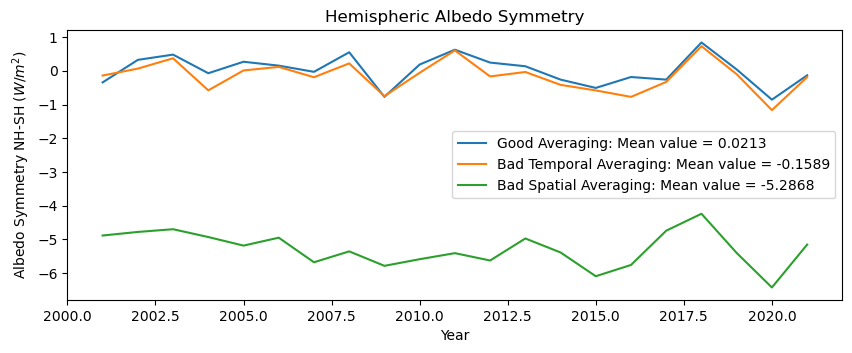

In [4]:
albedo_sym_14_mean = (sw_all_sky_14["nh"]-sw_all_sky_14["sh"]).mean().values
albedo_sym_bad_temporal_mean = (sw_all_sky_bad_temporal["nh"]-sw_all_sky_bad_temporal["sh"]).mean().values
albedo_sym_bad_spatial_mean = (sw_all_sky_bad_spatial["nh"]-sw_all_sky_bad_spatial["sh"]).mean().values

plt.plot(sw_all_sky_bad_spatial.year, sw_all_sky_14["nh"]-sw_all_sky_14["sh"], label=f"Good Averaging: Mean value = {albedo_sym_14_mean:.4f}")
plt.plot(sw_all_sky_bad_temporal.year, sw_all_sky_bad_temporal["nh"]-sw_all_sky_bad_temporal["sh"], label=f"Bad Temporal Averaging: Mean value = {albedo_sym_bad_temporal_mean:.4f}")
plt.plot(sw_all_sky_bad_spatial.year, sw_all_sky_bad_spatial["nh"]-sw_all_sky_bad_spatial["sh"], label=f"Bad Spatial Averaging: Mean value = {albedo_sym_bad_spatial_mean:.4f}")
plt.legend()
plt.title("Hemispheric Albedo Symmetry")
plt.xlabel("Year")
plt.ylabel("Albedo Symmetry NH-SH ($W/m^2$)")

## Trend Analysis

In [5]:
# Create the SW albedo data
has_good_avg = sw_all_sky_14["nh"]-sw_all_sky_14["sh"]
has_bad_temporal_avg = sw_all_sky_bad_temporal["nh"]-sw_all_sky_bad_temporal["sh"]
has_bad_spatial_avg = sw_all_sky_bad_spatial["nh"]-sw_all_sky_bad_spatial["sh"]

# Calculate the linear trend
albedo_good_trend = stats.linregress(has_bad_spatial_avg.year.values, has_good_avg.values)
albedo_bad_temporal_trend = stats.linregress(has_bad_temporal_avg.year.values, has_bad_temporal_avg.values)
albedo_bad_spatial_trend = stats.linregress(has_bad_spatial_avg.year.values, has_bad_spatial_avg.values)

print(f"Good Averaging Trend - {albedo_good_trend.slope} with p-value {albedo_good_trend.pvalue}")
print(f"Bad Temporal Averaging Trend - {albedo_bad_temporal_trend.slope} with p-value {albedo_bad_temporal_trend.pvalue}")
print(f"Bad Spatial Averaging Trend - {albedo_bad_spatial_trend.slope} with p-value {albedo_bad_spatial_trend.pvalue}")

Good Averaging Trend - -0.01687863465206798 with p-value 0.2965954628910877
Bad Temporal Averaging Trend - -0.01919842978957155 with p-value 0.25399860400625796
Bad Spatial Averaging Trend - -0.02580462571040618 with p-value 0.1718869201051811


# TOA Energy Balance Example

In [10]:
net_flux_good_avg = create_hemisphere_data(ds["toa_net_all_mon"], start_yr="2001", end_yr="2023")
net_flux_bad_temporal = create_hemisphere_data(ds["toa_net_all_mon"], start_yr="2001", end_yr="2023", time_weighting=-1)
net_flux_bad_spatial = create_hemisphere_data(ds["toa_net_all_mon"], start_yr="2001", end_yr="2023", space_weighting=-1)

Text(0, 0.5, 'Net TOA Flux ($W/m^2$)')

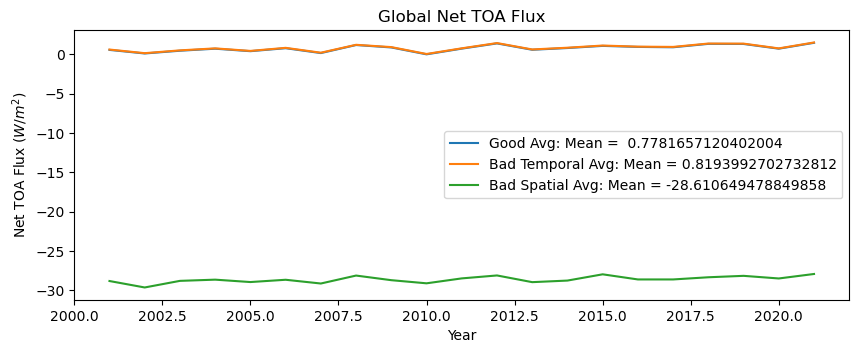

In [11]:
plt.plot(net_flux_good_avg.year, net_flux_good_avg["global"], label=f"Good Avg: Mean =  {net_flux_good_avg['global'].mean().values}")
plt.plot(net_flux_bad_temporal.year, net_flux_bad_temporal["global"], label=f"Bad Temporal Avg: Mean = {net_flux_bad_temporal['global'].mean().values}")
plt.plot(net_flux_bad_spatial.year, net_flux_bad_spatial["global"], label=f"Bad Spatial Avg: Mean = {net_flux_bad_spatial['global'].mean().values}")
plt.legend()
plt.title("Global Net TOA Flux")
plt.xlabel("Year")
plt.ylabel("Net TOA Flux ($W/m^2$)")
# Calculate the linear trend


In [12]:
# Calculate the linear trend
net_flux_14_trend = stats.linregress(net_flux_bad_temporal.year.values, net_flux_good_avg["global"].values)
net_flux_bad_temporal_trend = stats.linregress(net_flux_bad_temporal.year.values, net_flux_bad_temporal["global"].values)
net_flux_bad_spatial_trend = stats.linregress(net_flux_bad_spatial.year.values, net_flux_bad_spatial["global"].values)

print(f"Good Avg Trend = {net_flux_14_trend.slope} with p-value {net_flux_14_trend.pvalue}")
print(f"Bad Temporal Trend = {net_flux_bad_temporal_trend.slope} with p-value {net_flux_bad_temporal_trend.pvalue}")
print(f"Bad Spatial Trend = {net_flux_bad_spatial_trend.slope} with p-value {net_flux_bad_spatial_trend.pvalue}")

Good Avg Trend = 0.04256975171812094 with p-value 0.0022028626888483597
Bad Temporal Trend = 0.042502613853212905 with p-value 0.0022088969903608746
Bad Spatial Trend = 0.0414542380908727 with p-value 0.0036153405614114146


# NH TOA Flux

Text(0.5, 1.0, 'NH Net TOA Flux')

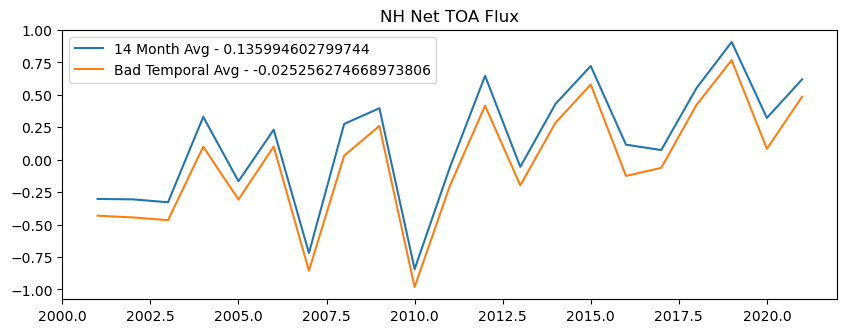

In [13]:
plt.plot(net_flux_good_avg.year, net_flux_good_avg["nh"], label=f"14 Month Avg - {net_flux_good_avg['nh'].mean().values}")
plt.plot(net_flux_bad_temporal.year, net_flux_bad_temporal["nh"], label=f"Bad Temporal Avg - {net_flux_bad_temporal['nh'].mean().values}")
#plt.plot(net_flux_bad_spatial.year, net_flux_bad_spatial["nh"], label=f"Bad Spatial Avg - {net_flux_bad_spatial['nh'].mean().values}")
plt.legend()
plt.title("NH Net TOA Flux")

In [14]:
# Calculate the linear trend
net_flux_14_trend = stats.linregress(net_flux_good_avg.year.values, net_flux_good_avg["nh"].values)
net_flux_bad_temporal_trend = stats.linregress(net_flux_bad_temporal.year.values, net_flux_bad_temporal["nh"].values)
net_flux_bad_spatial_trend = stats.linregress(net_flux_bad_spatial.year.values, net_flux_bad_spatial["nh"].values)

print(f"Good Avg Trend = {net_flux_14_trend.slope} with p-value {net_flux_14_trend.pvalue}")
print(f"Bad Temporal Trend = {net_flux_bad_temporal_trend.slope} with p-value {net_flux_bad_temporal_trend.pvalue}")
print(f"Bad Spatial Trend = {net_flux_bad_spatial_trend.slope} with p-value {net_flux_bad_spatial_trend.pvalue}")

Good Avg Trend = 0.04414055662550295 with p-value 0.004976970752049208
Bad Temporal Trend = 0.043348267459092864 with p-value 0.004943134102318947
Bad Spatial Trend = 0.03766764162333902 with p-value 0.02487960754586401


# SH TOA Flux

Text(0.5, 1.0, 'SH Net TOA Flux')

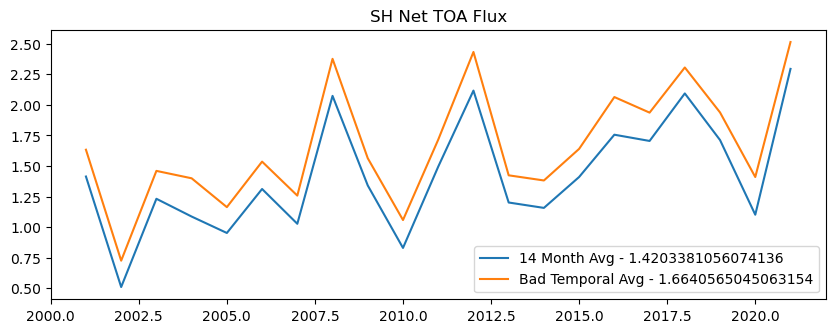

In [15]:
plt.plot(net_flux_good_avg.year, net_flux_good_avg["sh"], label=f"14 Month Avg - {net_flux_good_avg['sh'].mean().values}")
plt.plot(net_flux_bad_temporal.year, net_flux_bad_temporal["sh"], label=f"Bad Temporal Avg - {net_flux_bad_temporal['sh'].mean().values}")
plt.legend()
plt.title("SH Net TOA Flux")

In [16]:
# Calculate the linear trend
net_flux_14_trend = stats.linregress(net_flux_good_avg.year.values, net_flux_good_avg["sh"].values)
net_flux_bad_temporal_trend = stats.linregress(net_flux_bad_temporal.year.values, net_flux_bad_temporal["sh"].values)
net_flux_bad_spatial_trend = stats.linregress(net_flux_bad_spatial.year.values, net_flux_bad_spatial["sh"].values)

print(f"Good Avg Trend = {net_flux_14_trend.slope} with p-value {net_flux_14_trend.pvalue}")
print(f"Bad Temporal Trend = {net_flux_bad_temporal_trend.slope} with p-value {net_flux_bad_temporal_trend.pvalue}")
print(f"Bad Spatial Trend = {net_flux_bad_spatial_trend.slope} with p-value {net_flux_bad_spatial_trend.pvalue}")

Good Avg Trend = 0.040998943669162936 with p-value 0.010583180074100354
Bad Temporal Trend = 0.041656958556045176 with p-value 0.011228544898844325
Bad Spatial Trend = 0.045240834558406495 with p-value 0.011438785236935332
